In [3]:
import pandas as pd
import numpy as np

path=r"C:\Users\ps302\OneDrive\Desktop\Hydrology\src\Flood_Model\data\proceessed\flood_training_data_10k_clean.csv"
df = pd.read_csv(path)
df.head()

,easting,northing,point_id,distance_to_river,aspect,dem,flow_accumulation,twi,slope,flood,rainfall,drainage_density,ext_rainfall,lulc,soil
0,133952.230146,2.249638e+06,0,10993.2705,177.989240,183.269820,18,10.043777,1.200029e+00,0,1714.680084,0.008238,30.779120,40,29
1,206784.841335,2.468185e+06,1,8457.0740,317.784550,282.669430,1,8.483146,2.028161e+00,0,1561.825018,0.006385,34.464436,40,30
2,459671.933327,2.241227e+06,2,3313.8800,57.226437,0.000346,6,12.700654,9.576796e-07,0,1767.091847,0.045409,36.737860,80,36
3,44328.737440,2.570529e+06,3,9742.9820,152.312100,538.788700,2,9.058740,4.337976e+00,0,1424.827479,0.024082,32.841915,10,31
4,60077.196604,2.480489e+06,4,2313.1147,43.902390,298.437530,2,8.486233,7.265088e-01,0,1839.188680,0.027140,32.228870,50,31


In [5]:
df.columns

Index(['easting', 'northing', 'point_id', 'distance_to_river', 'aspect', 'dem',
       'flow_accumulation', 'twi', 'slope', 'flood', 'rainfall',
       'drainage_density', 'ext_rainfall', 'lulc', 'soil'],
      dtype='object')

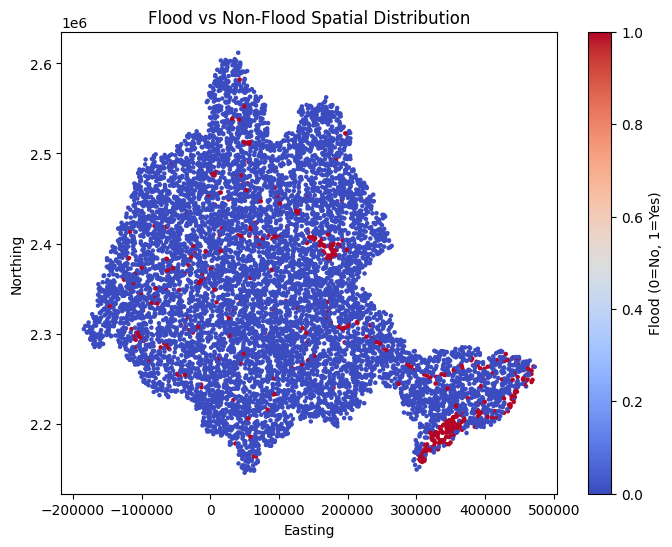

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df["easting"],
    df["northing"],
    c=df["flood"],
    cmap="coolwarm",
    s=5
)

plt.xlabel("Easting")
plt.ylabel("Northing")
plt.title("Flood vs Non-Flood Spatial Distribution")

plt.colorbar(label="Flood (0=No, 1=Yes)")

plt.show()

In [7]:
# Feature division
X = df.drop(['flood',"point_id", "easting", "northing"], axis=1)
y = df['flood']


In [8]:
# One-hot encode LULC
X = pd.get_dummies(X, columns=["lulc"], drop_first=True)

X.head()

,distance_to_river,aspect,dem,flow_accumulation,twi,slope,rainfall,drainage_density,ext_rainfall,soil,lulc_20,lulc_30,lulc_40,lulc_50,lulc_60,lulc_80,lulc_90,lulc_95
0,10993.2705,177.989240,183.269820,18,10.043777,1.200029e+00,1714.680084,0.008238,30.779120,29,False,False,True,False,False,False,False,False
1,8457.0740,317.784550,282.669430,1,8.483146,2.028161e+00,1561.825018,0.006385,34.464436,30,False,False,True,False,False,False,False,False
2,3313.8800,57.226437,0.000346,6,12.700654,9.576796e-07,1767.091847,0.045409,36.737860,36,False,False,False,False,False,True,False,False
3,9742.9820,152.312100,538.788700,2,9.058740,4.337976e+00,1424.827479,0.024082,32.841915,31,False,False,False,False,False,False,False,False
4,2313.1147,43.902390,298.437530,2,8.486233,7.265088e-01,1839.188680,0.027140,32.228870,31,False,False,False,True,False,False,False,False


In [9]:
X.columns

Index(['distance_to_river', 'aspect', 'dem', 'flow_accumulation', 'twi',
       'slope', 'rainfall', 'drainage_density', 'ext_rainfall', 'soil',
       'lulc_20', 'lulc_30', 'lulc_40', 'lulc_50', 'lulc_60', 'lulc_80',
       'lulc_90', 'lulc_95'],
      dtype='object')

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_train.shape, y_train.shape

((6828, 18), (6828,))

In [11]:
# XGBoost is tree-based, so standardization is not required
X_train = X_train.copy()
X_test = X_test.copy()

In [13]:
print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")


Training set: (6828, 18)
Test set: (2927, 18)


In [14]:
from sklearn.model_selection import StratifiedKFold

# stratified CV is better for imbalanced flood data
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [15]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

In [16]:
param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "gamma": [0, 0.1, 0.3],
    "min_child_weight": [1, 3, 5],
    "scale_pos_weight": [10, 15, 20, 25]
}

In [17]:
from sklearn.model_selection import GridSearchCV

grid_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring="recall",
    verbose=2,
    n_jobs=-1
)

In [18]:
# import warnings
# import joblib
# from google.colab import drive

# warnings.filterwarnings("ignore")

# # Fit
# grid_xgb.fit(X_train, y_train)

# # Best results
# print("Best Params:", grid_xgb.best_params_)
# print("Best Score:", grid_xgb.best_score_)

# # Save the best model to Google Drive
# try:
#     drive.mount('/content/drive')
#     model_path = '/content/drive/MyDrive/best_xgb_model.pkl'
#     joblib.dump(grid_xgb.best_estimator_, model_path)
#     print(f"Trained model saved to Google Drive as: {model_path}")
# except Exception as e:
#     print(f"Could not save to Drive: {e}")

In [25]:
booster = model.get_booster()
print("model.feature_names_in_ length:", len(getattr(model, "feature_names_in_", [])))
print("booster.num_features():", booster.num_features())
print("booster.feature_names:", booster.feature_names)
print("X columns length:", len(X.columns) if hasattr(X, "columns") else "NA")

model.feature_names_in_ length: 0
booster.num_features(): 11
booster.feature_names: None
X columns length: 18


In [ ]:
# Load the trained model -> with drainage_density
import joblib

xgb_model_path = r"C:\Users\ps302\OneDrive\Desktop\Hydrology\src\Flood_Model\model_training\xgboost\best_xgb_model.pkl"
model = joblib.load(xgb_model_path)

# use it
best_xgb = model
print(model.get_params())

{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'logloss', 'feature_types': None, 'feature_weights': None, 'gamma': 0.3, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.2, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 7, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 100, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': None, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': 5, 'subsample': 0.8, 'tree_method': None, 'validate_parameters': None, 'verbosity': None, 'use_label_encoder': False}


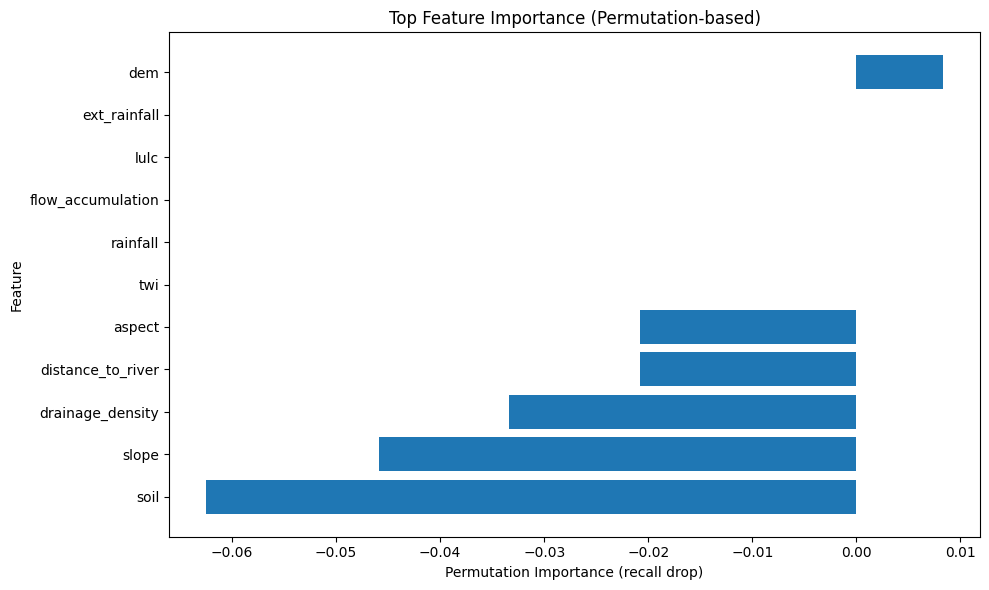

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

# Build an evaluation matrix with the exact feature count expected by the booster
expected_n_features = model.get_booster().num_features()

if hasattr(X, "shape") and X.shape[1] == expected_n_features:
    X_model = X.copy() if hasattr(X, "copy") else pd.DataFrame(X)
elif "df" in globals():
    X_candidate = df.drop(["flood", "point_id", "easting", "northing"], axis=1, errors="ignore")
    if X_candidate.shape[1] == expected_n_features:
        X_model = X_candidate
    else:
        raise ValueError(
            f"Feature mismatch persists. Booster expects {expected_n_features}, "
            f"candidate has {X_candidate.shape[1]}."
        )
else:
    raise ValueError("No feature source available to align with model.")

if "df" in globals() and "flood" in df.columns and len(df) == len(X_model):
    y_model = df["flood"]
elif "y" in globals() and len(y) == len(X_model):
    y_model = y
else:
    raise ValueError("Could not resolve target vector aligned with model features.")

# Sample a manageable holdout for stable and fast importance computation
test_ratio = min(0.3, max(0.1, 1000 / len(X_model)))
_, X_eval, _, y_eval = train_test_split(
    X_model,
    y_model,
    test_size=test_ratio,
    random_state=42,
    stratify=y_model
    )

result = permutation_importance(
    model,
    X_eval,
    y_eval,
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
    scoring="recall"
    )

feature_names = np.array(X_model.columns if hasattr(X_model, "columns") else [f"feature_{i}" for i in range(X_eval.shape[1])])
top_k = min(15, len(feature_names))
top_idx = np.argsort(result.importances_mean)[-top_k:]

plt.figure(figsize=(10, 6))
plt.barh(feature_names[top_idx], result.importances_mean[top_idx])
plt.xlabel("Permutation Importance (recall drop)")
plt.ylabel("Feature")
plt.title("Top Feature Importance (Permutation-based)")
plt.tight_layout()
plt.show()


Top 10 Features:
          feature  importance
 drainage_density    0.491001
             soil    0.105168
              dem    0.077435
          lulc_20    0.073728
distance_to_river    0.046483
            slope    0.038331
flow_accumulation    0.035392
              twi    0.035340
         rainfall    0.034973
     ext_rainfall    0.032002


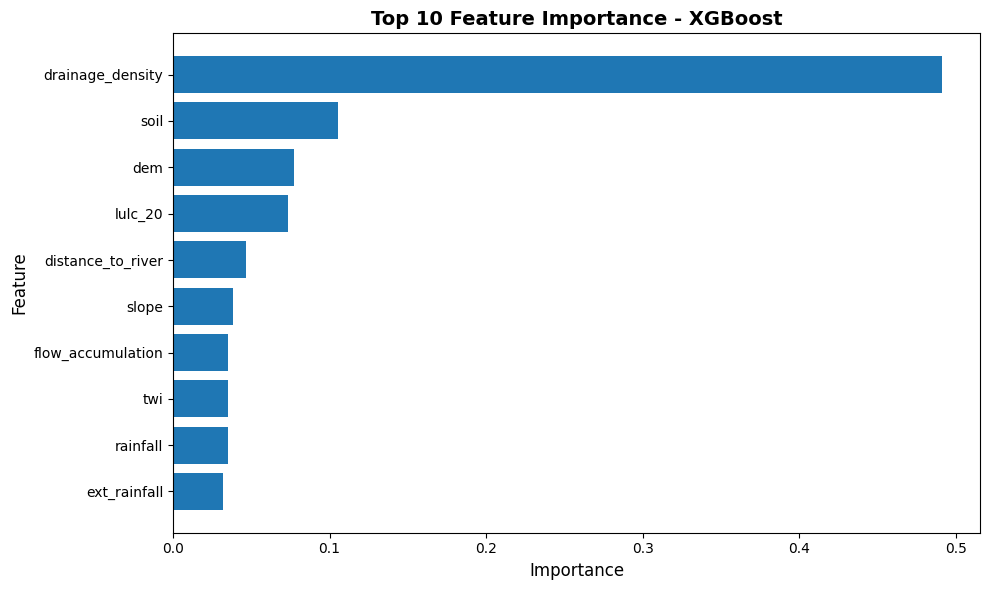

Feature importance plot displayed


In [28]:
importances = model.feature_importances_
feature_names = getattr(model, "feature_names_in_", None)
if feature_names is None or len(feature_names) != len(importances):
    feature_names = X.columns[: len(importances)]

feature_importance = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(10)
)

print("\nTop 10 Features:")
print(feature_importance.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importance)), feature_importance["importance"])
plt.yticks(range(len(feature_importance)), feature_importance["feature"])
plt.xlabel("Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.title("Top 10 Feature Importance - XGBoost", fontsize=14, fontweight="bold")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print("Feature importance plot displayed")

In [29]:
# Evaluate on test set
best_xgb = model
y_pred_xgb = best_xgb.predict(X_test)
y_pred_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]
y_pred_proba_xgb

ValueError: Feature shape mismatch, expected: 11, got 18

In [31]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score,accuracy_score, roc_curve, confusion_matrix
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print("\nTest Set Performance:")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1 Score: {f1_xgb:.4f}")
print(f"Accuracy: {acc_xgb:.4f}")
print(f"ROC AUC: {roc_auc_xgb:.4f}")
print(f"Confusion Matrix:\n{cm_xgb}")


Test Set Performance:
Precision: 0.8544
Recall: 0.7040
F1 Score: 0.7719
Accuracy: 0.9827
ROC AUC: 0.9537
Confusion Matrix:
[[2860   15]
 [  37   88]]


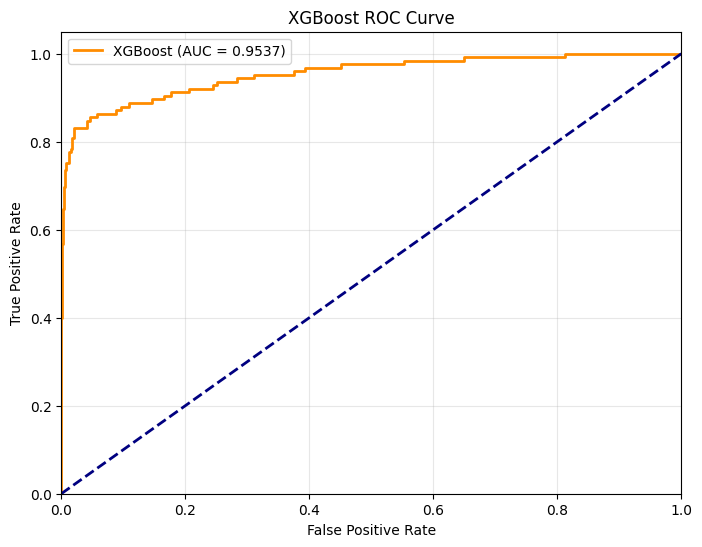

In [32]:

#  Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_xgb)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost (AUC = {roc_auc_xgb:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Prediction for new data
new_data = pd.DataFrame({
    "lulc": [40],
    "slope": [5.2],
    "dem": [120],
    "rainfall": [80],
    "flow_accumulation": [300],
    "twi": [10],
    "drainage_density": [2.5],
    "distance_to_river": [200],
    "aspect": [180],
    "ext_rainfall": [100],
    "soil": [3]
})

In [ ]:
# Apply same preprocessing to new data
new_data = pd.get_dummies(new_data, columns=["lulc"], drop_first=True)

# Align with training columns
new_data = new_data.reindex(columns=X_train.columns, fill_value=0)

In [ ]:
# Predict on new data
new_pred = best_xgb.predict(new_data)
new_pred_prob = best_xgb.predict_proba(new_data)[:, 1]

print("Prediction:", new_pred[0])
print("Flood Probability:", new_pred_prob[0])

In [37]:
print(df[['drainage_density','flow_accumulation','twi','distance_to_river']].corr())

                   drainage_density  flow_accumulation       twi  \
drainage_density           1.000000          -0.065042  0.107181   
flow_accumulation         -0.065042           1.000000 -0.017970   
twi                        0.107181          -0.017970  1.000000   
distance_to_river          0.436093          -0.029334  0.564282   

                   distance_to_river  
drainage_density            0.436093  
flow_accumulation          -0.029334  
twi                         0.564282  
distance_to_river           1.000000  


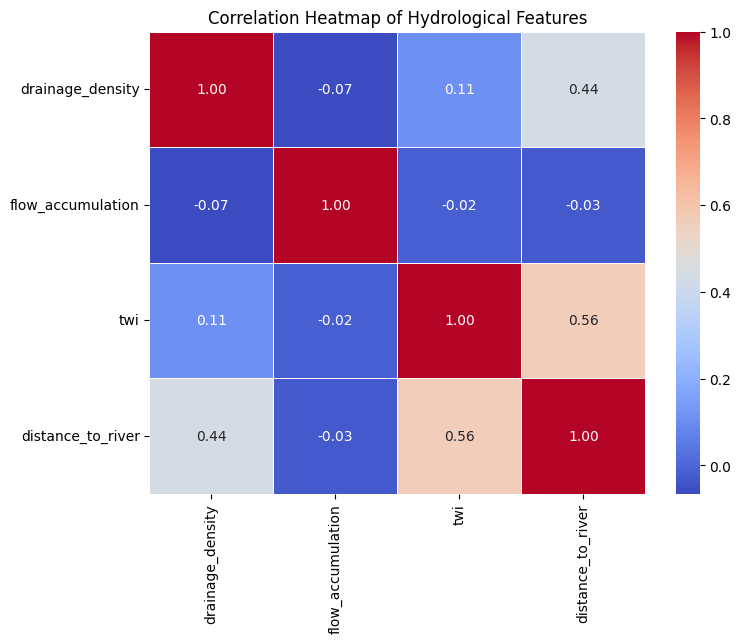

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the features to correlate
corr_features = ['drainage_density', 'flow_accumulation', 'twi', 'distance_to_river']
corr_matrix = df[corr_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Hydrological Features')
plt.show()

###### Although drainage density appeared as the most important feature in XGBoost, SHAP analysis indicated that this dominance was likely due to model bias rather than true hydrological significance. Correlation analysis showed it was not strongly related to other flow-related variables, and domain knowledge suggests that elevation and distance to river are more critical for flood occurrence. Therefore, to improve interpretability and ensure physically meaningful predictions, drainage density was excluded and the model was retrained

In [39]:
# Feature division
X = df.drop(['flood',"point_id", "easting", "northing", "drainage_density"], axis=1)
y = df['flood']
X.columns

Index(['distance_to_river', 'aspect', 'dem', 'flow_accumulation', 'twi',
       'slope', 'rainfall', 'ext_rainfall', 'lulc', 'soil'],
      dtype='object')

In [40]:
# Split the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [41]:
# Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

###### To improve flood-event detection, the LightGBM model was optimized for recall using stratified cross-validation, class imbalance weighting, and post-training probability threshold tuning. This was done because missing flood-prone locations is more critical than generating additional false alarms

In [42]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# stratified CV is better for imbalanced flood data
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "gamma": [0, 0.1, 0.3],
    "min_child_weight": [1, 3, 5],
    "scale_pos_weight": [10, 15, 20, 25]
}

In [43]:
grid_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring="recall",
    verbose=2,
    n_jobs=-1
)


In [ ]:
# import warnings
# warnings.filterwarnings("ignore")
# grid_xgb.fit(X_train, y_train)

# best_model_wo_dd = grid_xgb.best_estimator_

# print("Best Parameters:")
# print(grid_xgb.best_params_)

# print("\nBest CV Recall:")
# print(grid_xgb.best_score_)

In [47]:
# Load the trained model
from pathlib import Path
import joblib

# Resolve project root even if notebook is run from a subfolder
project_root = Path.cwd()
if not (project_root / "src").exists():
    for parent in [project_root, *project_root.parents]:
        if (parent / "src").exists():
            project_root = parent
            break

xgb_model_path = project_root / "src" / "Flood_Model" / "model_training" / "xgboost" / "best_xgb_model_wo_dd_stratified_cv.pkl"

# Fallback to alternate saved model name if needed
if not xgb_model_path.exists():
    fallback_path = project_root / "src" / "Flood_Model" / "model_training" / "xgboost" / "best_xgb_model_wo_dd.pkl"
    if fallback_path.exists():
        xgb_model_path = fallback_path
    else:
        raise FileNotFoundError(
            f"Model file not found. Checked:\n{xgb_model_path}\n{fallback_path}"
        )

model = joblib.load(xgb_model_path)

# use it
best_xgb = model
print(f"Loaded model from: {xgb_model_path}")
print(model.get_params())

Loaded model from: c:\Users\ps302\OneDrive\Desktop\Hydrology\src\Flood_Model\model_training\xgboost\best_xgb_model_wo_dd_stratified_cv.pkl
{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'logloss', 'feature_types': None, 'feature_weights': None, 'gamma': 0.1, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.03, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 3, 'max_leaves': None, 'min_child_weight': 5, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 200, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': 25, 'subsample': 0.8, 'tree_method':

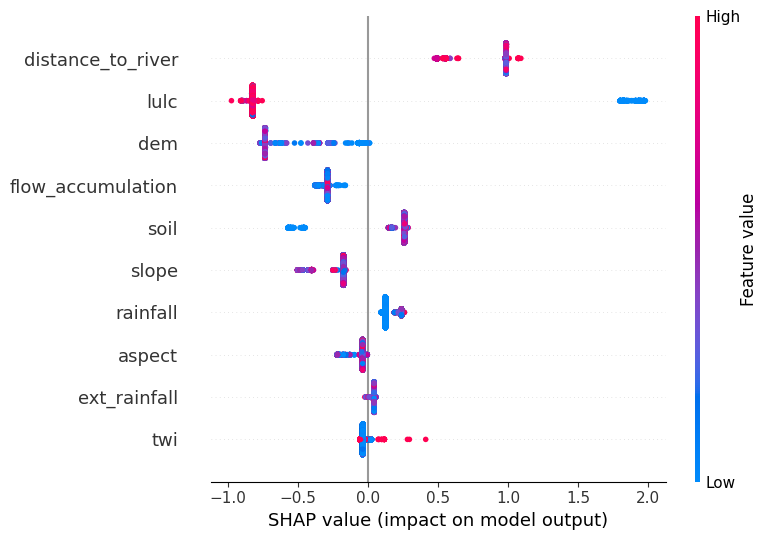

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

# Build an evaluation matrix with the exact feature count expected by the booster
expected_n_features = model.get_booster().num_features()

if hasattr(X, "shape") and X.shape[1] == expected_n_features:
    X_model = X.copy() if hasattr(X, "copy") else pd.DataFrame(X)
elif "df" in globals():
    X_candidate = df.drop(["flood", "point_id", "easting", "northing"], axis=1, errors="ignore")
    if X_candidate.shape[1] == expected_n_features:
        X_model = X_candidate
    else:
        raise ValueError(
            f"Feature mismatch persists. Booster expects {expected_n_features}, "
            f"candidate has {X_candidate.shape[1]}."
        )
else:
    raise ValueError("No feature source available to align with model.")

if "df" in globals() and "flood" in df.columns and len(df) == len(X_model):
    y_model = df["flood"]
elif "y" in globals() and len(y) == len(X_model):
    y_model = y
else:
    raise ValueError("Could not resolve target vector aligned with model features.")

# Sample a manageable holdout for stable and fast importance computation
test_ratio = min(0.3, max(0.1, 1000 / len(X_model)))
_, X_eval, _, y_eval = train_test_split(
    X_model,
    y_model,
    test_size=test_ratio,
    random_state=42,
    stratify=y_model
    )

result = permutation_importance(
    model,
    X_eval,
    y_eval,
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
    scoring="recall"
    )

feature_names = np.array(X_model.columns if hasattr(X_model, "columns") else [f"feature_{i}" for i in range(X_eval.shape[1])])
top_k = min(15, len(feature_names))
top_idx = np.argsort(result.importances_mean)[-top_k:]

plt.figure(figsize=(10, 6))
plt.barh(feature_names[top_idx], result.importances_mean[top_idx])
plt.xlabel("Permutation Importance (recall drop)")
plt.ylabel("Feature")
plt.title("Top Feature Importance (Permutation-based)")
plt.tight_layout()
plt.show()


Top 10 Features:
          feature  importance
             lulc    0.327854
             soil    0.135600
distance_to_river    0.098159
              dem    0.091492
flow_accumulation    0.087405
         rainfall    0.064335
              twi    0.056102
            slope    0.052669
           aspect    0.047815
     ext_rainfall    0.038569


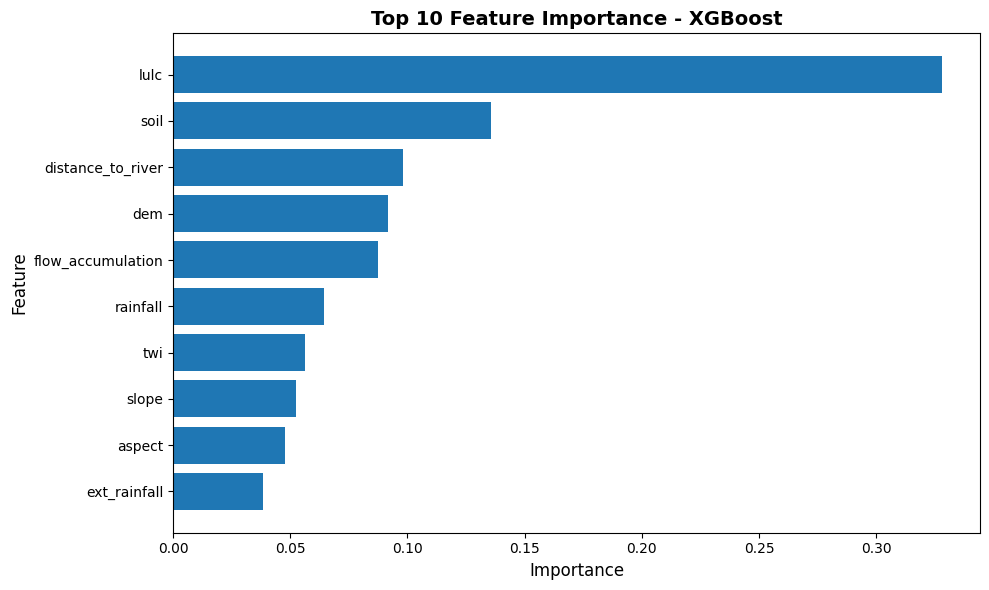

Feature importance plot displayed


In [ ]:
importances = model.feature_importances_
feature_names = getattr(model, "feature_names_in_", None)
if feature_names is None or len(feature_names) != len(importances):
    feature_names = X.columns[: len(importances)]

feature_importance = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(10)
)

print("\nTop 10 Features:")
print(feature_importance.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importance)), feature_importance["importance"])
plt.yticks(range(len(feature_importance)), feature_importance["feature"])
plt.xlabel("Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.title("Top 10 Feature Importance - XGBoost", fontsize=14, fontweight="bold")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print("Feature importance plot displayed")

In [51]:
# Evaluate on test set
best_xgb = model
y_pred_xgb = best_xgb.predict(X_test)
y_pred_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]
y_pred_proba_xgb

array([0.05609639, 0.02404628, 0.28710347, ..., 0.24849984, 0.18567874,
       0.01684954], shape=(3000,), dtype=float32)

In [52]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score,accuracy_score, roc_curve, confusion_matrix
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print("\nTest Set Performance:")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1 Score: {f1_xgb:.4f}")
print(f"Accuracy: {acc_xgb:.4f}")
print(f"ROC AUC: {roc_auc_xgb:.4f}")
print(f"Confusion Matrix:\n{cm_xgb}")


Test Set Performance:
Precision: 0.2991
Recall: 0.8160
F1 Score: 0.4378
Accuracy: 0.9127
ROC AUC: 0.9275
Confusion Matrix:
[[2636  239]
 [  23  102]]


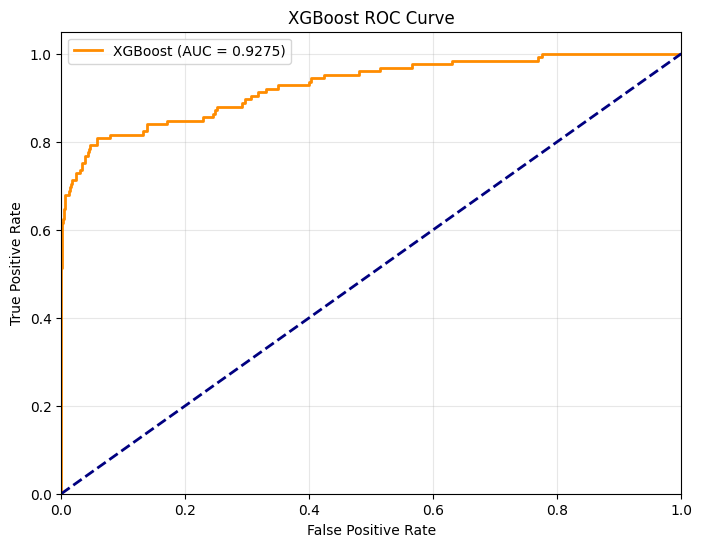

In [53]:

#  Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_xgb)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost (AUC = {roc_auc_xgb:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

###### After removing drainage density, the model showed a decrease in overall accuracy but improved recall for the flood class, indicating better detection of actual flood events. Although false positives increased, this trade-off is acceptable in flood susceptibility modeling, where missing a flood event is more critical than issuing a false warning

### Common Ananlysis


Model Metrics Comparison


,Accuracy,Precision,Recall,F1,ROC-AUC,Specificity
XGBoost (with drainage_density),0.9827,0.8544,0.704,0.7719,0.9537,0.9948
XGBoost (without drainage_density),0.9127,0.2991,0.816,0.4378,0.9275,0.9169


Confusion Matrix Values Comparison


,TN,FP,FN,TP
XGBoost (with drainage_density),2860,15,37,88
XGBoost (without drainage_density),2636,239,23,102


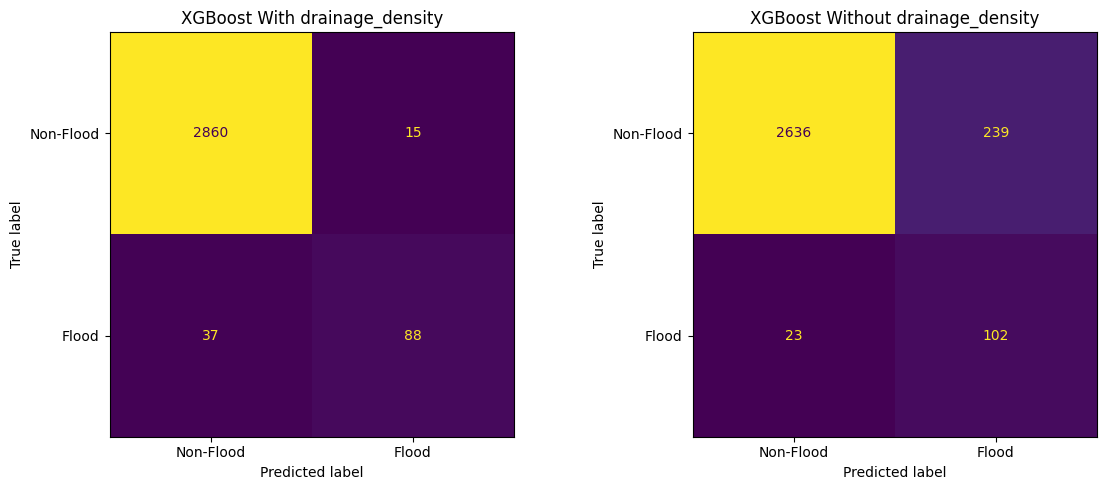

In [55]:
# Comparison of both saved XGBoost models (with vs without drainage_density)
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)


def resolve_project_root():
    root = Path.cwd()
    if (root / "src").exists():
        return root
    for parent in root.parents:
        if (parent / "src").exists():
            return parent
    raise FileNotFoundError("Could not resolve project root containing 'src' directory.")


def evaluate_model(model, X_test_scaled, y_test):
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "Specificity": specificity,
    }

    cm = np.array([[tn, fp], [fn, tp]])
    cm_summary = {
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    }

    return metrics, cm, cm_summary


# Build feature sets from current df
y_all = df["flood"]
X_with_dd = df.drop(["flood", "point_id", "easting", "northing"], axis=1)
X_without_dd = df.drop(["flood", "point_id", "easting", "northing", "drainage_density"], axis=1)

# Use the same row split for both models
idx_train, idx_test = train_test_split(
    df.index,
    test_size=0.3,
    random_state=42,
    stratify=y_all,
)

# With drainage density
scaler_with = StandardScaler()
X_with_train_scaled = scaler_with.fit_transform(X_with_dd.loc[idx_train])
X_with_test_scaled = scaler_with.transform(X_with_dd.loc[idx_test])
X_with_test_scaled = pd.DataFrame(
    X_with_test_scaled,
    columns=X_with_dd.columns,
    index=idx_test,
)
y_test_with = y_all.loc[idx_test]

# Without drainage density
scaler_without = StandardScaler()
X_without_train_scaled = scaler_without.fit_transform(X_without_dd.loc[idx_train])
X_without_test_scaled = scaler_without.transform(X_without_dd.loc[idx_test])
X_without_test_scaled = pd.DataFrame(
    X_without_test_scaled,
    columns=X_without_dd.columns,
    index=idx_test,
)
y_test_without = y_all.loc[idx_test]

# Load both trained XGBoost models
project_root = resolve_project_root()
model_with_dd_path = project_root / "src" / "Flood_Model" / "model_training" / "xgboost" / "best_xgb_model.pkl"
model_without_dd_path = project_root / "src" / "Flood_Model" / "model_training" / "xgboost" / "best_xgb_model_wo_dd_stratified_cv.pkl"

if not model_without_dd_path.exists():
    fallback_without_dd = project_root / "src" / "Flood_Model" / "model_training" / "xgboost" / "best_xgb_model_wo_dd.pkl"
    if fallback_without_dd.exists():
        model_without_dd_path = fallback_without_dd
    else:
        raise FileNotFoundError(
            f"Without-drainage model not found. Checked:\n{model_without_dd_path}\n{fallback_without_dd}"
        )

model_with_dd = joblib.load(model_with_dd_path)
model_without_dd = joblib.load(model_without_dd_path)

# Evaluate both models
metrics_with, cm_with, cm_summary_with = evaluate_model(model_with_dd, X_with_test_scaled, y_test_with)
metrics_without, cm_without, cm_summary_without = evaluate_model(model_without_dd, X_without_test_scaled, y_test_without)

results = {
    "XGBoost (with drainage_density)": metrics_with,
    "XGBoost (without drainage_density)": metrics_without,
}
cm_results = {
    "XGBoost (with drainage_density)": cm_summary_with,
    "XGBoost (without drainage_density)": cm_summary_without,
}

comparison_df = pd.DataFrame(results).T.round(4)
cm_comparison_df = pd.DataFrame(cm_results).T

print("Model Metrics Comparison")
display(comparison_df)

print("Confusion Matrix Values Comparison")
display(cm_comparison_df)

# Plot side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_with, display_labels=["Non-Flood", "Flood"]).plot(
    ax=axes[0],
    values_format="d",
    colorbar=False,
)
axes[0].set_title("XGBoost With drainage_density")

ConfusionMatrixDisplay(confusion_matrix=cm_without, display_labels=["Non-Flood", "Flood"]).plot(
    ax=axes[1],
    values_format="d",
    colorbar=False,
)
axes[1].set_title("XGBoost Without drainage_density")

plt.tight_layout()
plt.show()

In [56]:
# # Fit
# grid_xgb.fit(X_train, y_train)

# # Best results
# print("Best Params:", grid_xgb.best_params_)
# print("Best Score:", grid_xgb.best_score_)

In [ ]:
import joblib

# Save the best model found by GridSearchCV
joblib.dump(grid_xgb.best_estimator_, 'best_xgb_model.pkl')

print("Trained model saved as 'best_xgb_model.pkl'")

Trained model saved as 'best_xgb_model.pkl'


In [ ]:
print("Best Params:", grid_xgb.best_params_)
print("Best Score:", grid_xgb.best_score_)

Best Params: {'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'scale_pos_weight': 5, 'subsample': 1.0}
Best Score: 0.7496595660730223


In [62]:
# Load the trained model
from pathlib import Path
import joblib

# Resolve project root even if notebook is run from a subfolder
project_root = Path.cwd()
if not (project_root / "src").exists():
    for parent in [project_root, *project_root.parents]:
        if (parent / "src").exists():
            project_root = parent
            break

xgb_model_path = project_root / "src" / "Flood_Model" / "model_training" / "xgboost" / "best_xgb_model_wo_dd.pkl"

model = joblib.load(xgb_model_path)

# use it
best_xgb = model
print(f"Loaded model from: {xgb_model_path}")
print(model.get_params())

Loaded model from: c:\Users\ps302\OneDrive\Desktop\Hydrology\src\Flood_Model\model_training\xgboost\best_xgb_model_wo_dd.pkl
{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 1.0, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'logloss', 'feature_types': None, 'feature_weights': None, 'gamma': 0.3, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.1, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 3, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 100, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': None, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': 10, 'subsample': 1.0, 'tree_method': None, 'va


Top 10 Features:
          feature  importance
             lulc    0.430660
             soil    0.126506
              dem    0.092597
distance_to_river    0.072128
flow_accumulation    0.068898
              twi    0.054645
         rainfall    0.043043
            slope    0.042176
           aspect    0.037788
     ext_rainfall    0.031559


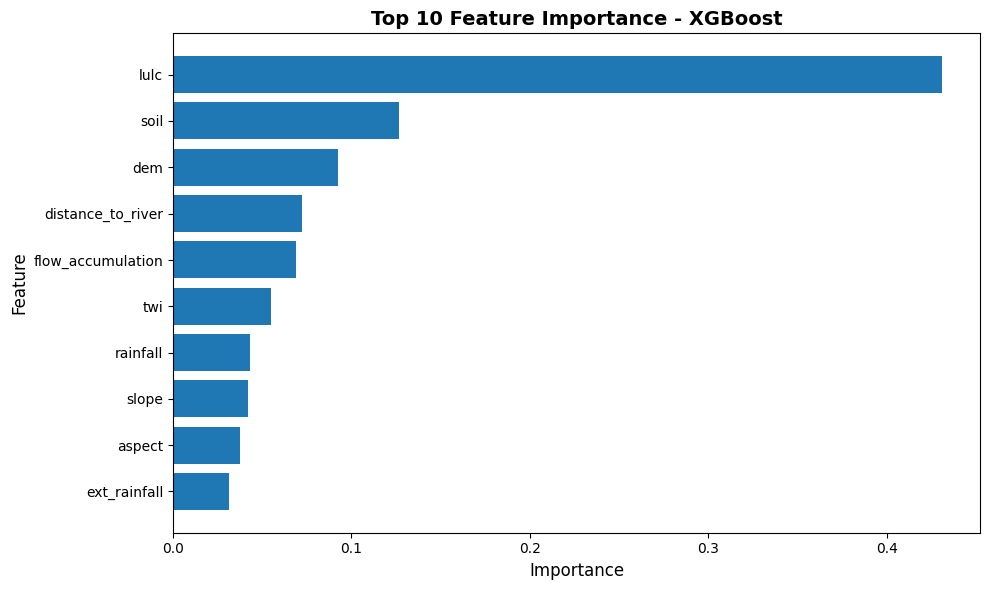

Feature importance plot displayed


In [ ]:
importances = model.feature_importances_
feature_names = getattr(model, "feature_names_in_", None)
if feature_names is None or len(feature_names) != len(importances):
    feature_names = X.columns[: len(importances)]

feature_importance = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(10)
)

print("\nTop 10 Features:")
print(feature_importance.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importance)), feature_importance["importance"])
plt.yticks(range(len(feature_importance)), feature_importance["feature"])
plt.xlabel("Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.title("Top 10 Feature Importance - XGBoost", fontsize=14, fontweight="bold")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print("Feature importance plot displayed")

In [59]:
# Evaluate on test set
best_xgb = model
y_pred_xgb = best_xgb.predict(X_test)
y_pred_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]
y_pred_proba_xgb

array([0.03113455, 0.00916631, 0.12695566, ..., 0.14577366, 0.07250693,
       0.00650324], shape=(3000,), dtype=float32)

In [60]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score,accuracy_score, roc_curve, confusion_matrix
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print("\nTest Set Performance:")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1 Score: {f1_xgb:.4f}")
print(f"Accuracy: {acc_xgb:.4f}")
print(f"ROC AUC: {roc_auc_xgb:.4f}")
print(f"Confusion Matrix:\n{cm_xgb}")


Test Set Performance:
Precision: 0.5311
Recall: 0.7520
F1 Score: 0.6225
Accuracy: 0.9620
ROC AUC: 0.9299
Confusion Matrix:
[[2792   83]
 [  31   94]]


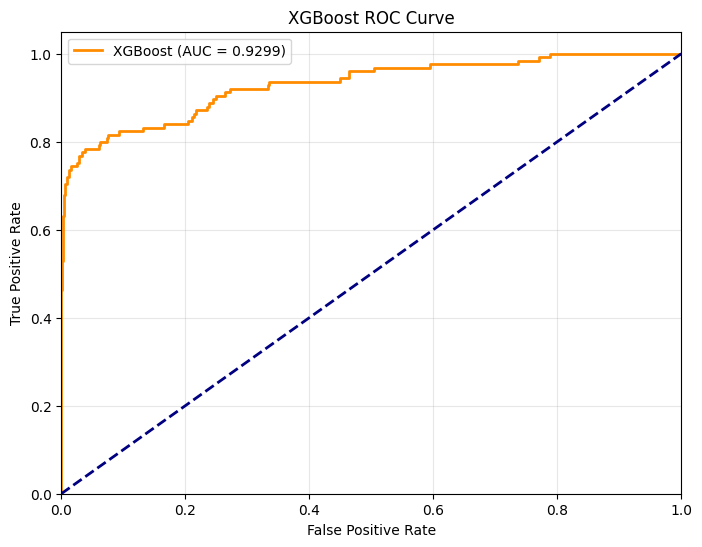

In [61]:

#  Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_xgb)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost (AUC = {roc_auc_xgb:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()